# 2.14 Analítica de Datos: Tipos de Gráficos y Análisis Exploratorio

**Clase 1 — Versión Python con Matplotlib, Seaborn y Pandas**

Sergio Alejandro Holguín García

---

## Contenido

1. Por qué son importantes los datos
2. Configuración del entorno
3. Tipos de gráficos:
   - Gráfico de barras
   - Gráfico de columnas
   - Gráfico circular (pastel)
   - Gráfico de líneas
   - Mapa de calor (heatmap)
   - Gráfico de dispersión (scatter plot)
   - Diagrama de caja (box plot)
   - Histograma
4. Análisis exploratorio: identificación de valores atípicos

---

## 1. ¿Por qué son importantes los datos?

Los datos nos ayudan a **tomar mejores decisiones**, entender lo que está pasando y encontrar patrones que a simple vista no se ven.

Cuando sabemos interpretarlos bien, podemos descubrir información valiosa y compartirla de forma clara, para que otros también la comprendan y la usen.

La clave está en **hacer sencillo lo complejo**: transformar números y tablas en mensajes fáciles de entender.

Para lograrlo necesitamos dos cosas:

1. **Saber qué tipo de gráfico usar** según la pregunta que queremos responder.
2. **Saber explorar los datos** antes de visualizarlos (limpieza, valores extremos, distribución).

Este notebook recorre ambos aspectos con ejemplos prácticos en Python.

---

## 2. Configuración del entorno

Importamos las librerías que vamos a usar en todo el notebook.

In [1]:
# Manipulación numérica y de tablas
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Semilla para que los datos aleatorios sean reproducibles
# (cada vez que ejecutemos el notebook obtendremos los mismos valores)
np.random.seed(42)

# Configuración estética general para que los gráficos se vean limpios
sns.set_style('whitegrid')           # Fondo blanco con cuadrícula sutil
plt.rcParams['figure.dpi'] = 100     # Resolución
plt.rcParams['axes.titleweight'] = 'bold'  # Títulos en negrita por defecto

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


---
## 3. Tipos de gráficos

Cada gráfico tiene un **propósito**. Elegir el correcto facilita la lectura; elegir el incorrecto confunde al lector. A continuación veremos los más usados.

### 3.1 Gráfico de barras

**¿Qué es?** Representa datos con barras rectangulares horizontales. Cada barra muestra el valor de una categoría.

**¿Cuándo usarlo?** Para **comparar cantidades entre categorías**. Es especialmente útil cuando los nombres de las categorías son largos (porque caben en horizontal) o cuando hay muchas categorías.

**Ejemplo:** comparar ventas por producto.

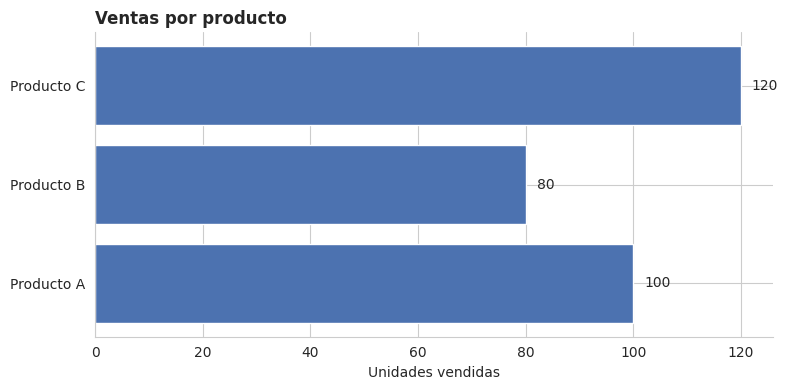

In [2]:
# Datos del ejemplo: ventas por producto
productos = ['Producto A', 'Producto B', 'Producto C']
ventas    = [100, 80, 120]

# Crear la figura y el eje
fig, ax = plt.subplots(figsize=(8, 4))

# barh = bar horizontal (gráfico de BARRAS, no de columnas)
ax.barh(productos, ventas, color='#4c72b0')

# Añadir el valor numérico al final de cada barra para facilitar la lectura
for i, v in enumerate(ventas):
    ax.text(v + 2, i, str(v), va='center', fontsize=10)

# Títulos y etiquetas
ax.set_title('Ventas por producto', loc='left')
ax.set_xlabel('Unidades vendidas')

# Quitar bordes superiores y derechos para una apariencia limpia
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación:** El Producto C lidera con 120 unidades, seguido de A (100) y B (80). En un gráfico de barras horizontal el ojo compara longitudes, que es la tarea visual más precisa para los seres humanos.

### 3.2 Gráfico de columnas

**¿Qué es?** Similar al de barras, pero **vertical**. Las categorías están en el eje X y los valores en el eje Y.

**¿Cuándo usarlo?** Para comparar valores **a lo largo del tiempo** o entre categorías cuando los nombres son cortos. Es la opción natural para series temporales discretas (trimestres, meses, años).

**Ejemplo:** ventas por trimestre comparando dos años.

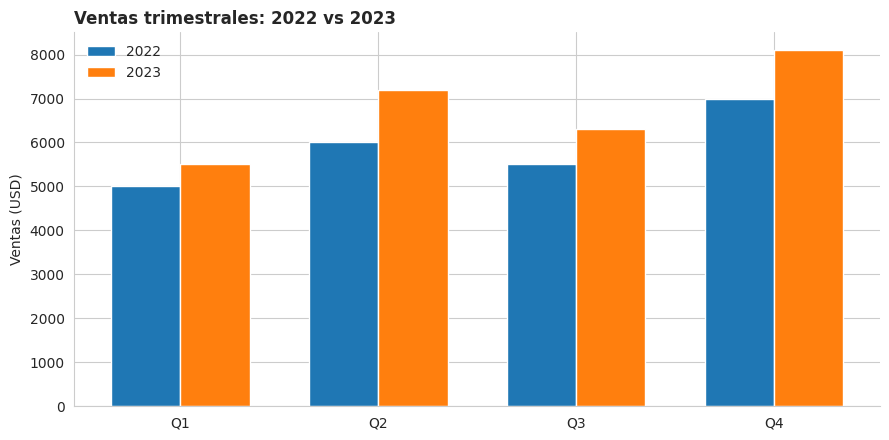

In [3]:
# Datos: ventas trimestrales en dos años distintos
trimestres  = ['Q1', 'Q2', 'Q3', 'Q4']
ventas_2022 = [5000, 6000, 5500, 7000]
ventas_2023 = [5500, 7200, 6300, 8100]

# Posiciones numéricas para colocar las columnas lado a lado
x     = np.arange(len(trimestres))   # [0, 1, 2, 3]
ancho = 0.35                          # ancho de cada columna

fig, ax = plt.subplots(figsize=(9, 4.5))

# Dos series: una desplazada a la izquierda y otra a la derecha del centro
ax.bar(x - ancho/2, ventas_2022, width=ancho, label='2022', color='#1f77b4')
ax.bar(x + ancho/2, ventas_2023, width=ancho, label='2023', color='#ff7f0e')

# Configurar las etiquetas del eje X (los trimestres)
ax.set_xticks(x)
ax.set_xticklabels(trimestres)

ax.set_title('Ventas trimestrales: 2022 vs 2023', loc='left')
ax.set_ylabel('Ventas (USD)')
ax.legend(frameon=False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación:** En todos los trimestres 2023 superó a 2022. La diferencia más grande está en Q4, lo que indica una temporada alta cada vez más fuerte.

**Diferencia entre barras y columnas:**

| Característica | Barras (horizontal) | Columnas (vertical) |
|---|---|---|
| Orientación | Horizontal | Vertical |
| Ideal para | Categorías con nombres largos | Series temporales |
| Función matplotlib | `ax.barh()` | `ax.bar()` |

### 3.3 Gráfico circular (pastel)

**¿Qué es?** Muestra proporciones como segmentos de un círculo. La suma de todos los segmentos representa el 100%.

**¿Cuándo usarlo?** Para mostrar **partes de un total**, idealmente con **pocas categorías** (entre 2 y 5). Con más categorías el ojo no compara bien los ángulos.

**Ejemplo:** distribución del presupuesto.

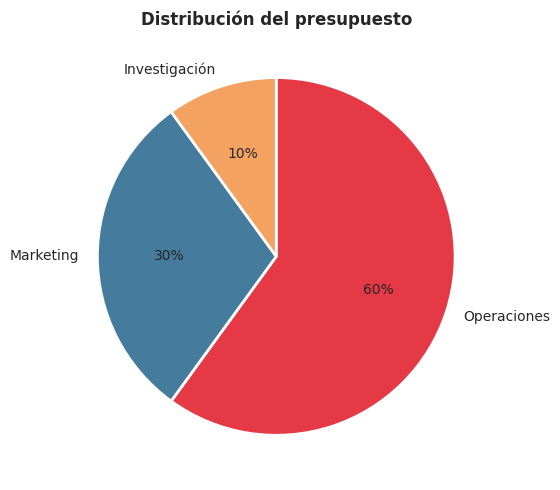

In [4]:
# Datos: distribución porcentual del presupuesto
categorias  = ['Operaciones', 'Marketing', 'Investigación']
porcentajes = [60, 30, 10]
colores     = ['#e63946', '#457b9d', '#f4a261']

fig, ax = plt.subplots(figsize=(7, 5))

ax.pie(
    porcentajes,
    labels=categorias,
    colors=colores,
    autopct='%1.0f%%',     # Muestra el porcentaje dentro de cada porción
    startangle=90,          # Inicia desde arriba (12 en punto)
    counterclock=False,     # Sentido horario, lectura más natural
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}  # Borde blanco entre porciones
)

ax.set_title('Distribución del presupuesto')
plt.tight_layout()
plt.show()

**Interpretación:** Operaciones se lleva la mayor parte del presupuesto (60%), Marketing el 30% e Investigación el 10%.

**Advertencia:** si tuviéramos 10 o 15 categorías, este gráfico se volvería ilegible. En esos casos es mejor un **gráfico de barras** ordenado de mayor a menor.

### 3.4 Gráfico de líneas

**¿Qué es?** Usa puntos conectados por líneas para mostrar **tendencias**.

**¿Cuándo usarlo?** Para mostrar **evolución en el tiempo**. Es el gráfico ideal cuando el eje X representa una variable continua u ordenada (días, meses, años).

**Ejemplo:** evolución de visitas a una página web durante 12 meses.

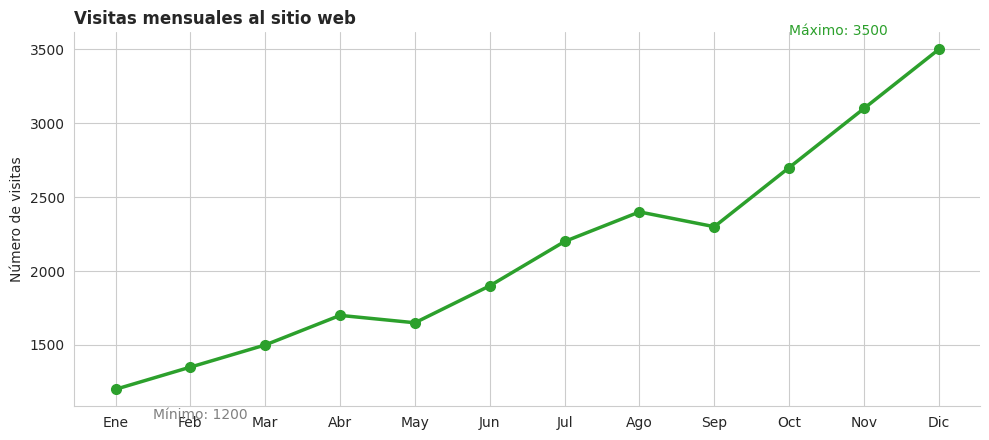

In [5]:
# Datos: visitas mensuales a un sitio web
meses   = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun',
           'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']
visitas = [1200, 1350, 1500, 1700, 1650, 1900,
           2200, 2400, 2300, 2700, 3100, 3500]

fig, ax = plt.subplots(figsize=(10, 4.5))

# Línea con marcadores en cada punto para destacar las observaciones
ax.plot(meses, visitas,
        color='#2ca02c', linewidth=2.5,
        marker='o', markersize=7)

# Resaltar el punto máximo y mínimo con anotaciones
idx_max = visitas.index(max(visitas))
idx_min = visitas.index(min(visitas))

ax.annotate(f'Máximo: {max(visitas)}',
            xy=(idx_max, max(visitas)),
            xytext=(idx_max - 2, max(visitas) + 100),
            fontsize=10, color='#2ca02c')

ax.annotate(f'Mínimo: {min(visitas)}',
            xy=(idx_min, min(visitas)),
            xytext=(idx_min + 0.5, min(visitas) - 200),
            fontsize=10, color='gray')

ax.set_title('Visitas mensuales al sitio web', loc='left')
ax.set_ylabel('Número de visitas')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación:** Las visitas crecieron de manera sostenida durante el año, casi triplicándose entre enero (1.200) y diciembre (3.500). La línea facilita ver no solo los valores, sino también el **ritmo** del crecimiento.

### 3.5 Mapa de calor (heatmap)

**¿Qué es?** Representa valores usando **colores en una matriz**. Cada celda toma un color según su valor numérico.

**¿Cuándo usarlo?** Para ver **patrones y concentraciones** cuando tenemos datos cruzados por dos dimensiones (por ejemplo: día de la semana × hora del día, o región × categoría de producto).

**Ejemplo:** tiempos de respuesta de servicio al cliente por área geográfica y día de la semana.

In [6]:
# Construimos una matriz simulada: filas = regiones, columnas = días
regiones = ['Norte', 'Sur', 'Este', 'Oeste', 'Centro']
dias     = ['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom']

# Tiempos de respuesta en minutos (datos aleatorios entre 5 y 60)
tiempos = np.random.randint(5, 60, size=(len(regiones), len(dias)))

# Convertir a DataFrame para que seaborn etiquete los ejes automáticamente
df_tiempos = pd.DataFrame(tiempos, index=regiones, columns=dias)
print('Matriz de tiempos de respuesta (en minutos):')
df_tiempos

Matriz de tiempos de respuesta (en minutos):


,Lun,Mar,Mié,Jue,Vie,Sáb,Dom
Norte,43,56,33,19,47,12,25
Sur,43,23,27,15,15,28,57
Este,40,44,28,7,26,57,6
Oeste,28,48,34,42,6,25,37
Centro,16,26,48,29,53,31,46


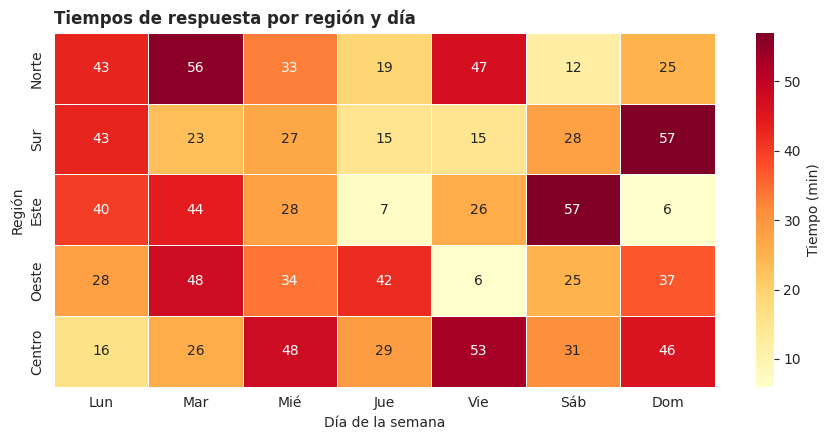

In [7]:
fig, ax = plt.subplots(figsize=(9, 4.5))

# annot=True escribe el número dentro de cada celda
# cmap='YlOrRd' = paleta secuencial (amarillo -> rojo): bajo a alto
sns.heatmap(df_tiempos,
            annot=True, fmt='d',
            cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Tiempo (min)'},
            ax=ax)

ax.set_title('Tiempos de respuesta por región y día', loc='left')
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Región')

plt.tight_layout()
plt.show()

**Interpretación:** Los colores más intensos (rojos) marcan los puntos donde el servicio fue más lento. De un vistazo se identifican las combinaciones región/día que requieren atención.

**Consejo:** elige la paleta según el tipo de dato:
- **Secuencial** (`YlOrRd`, `Blues`, `viridis`): valores que van de menos a más.
- **Divergente** (`RdBu`, `coolwarm`): valores con un punto medio (por ejemplo, ganancia/pérdida).
- **Cualitativa** (`Set2`, `tab10`): categorías sin orden.

### 3.6 Gráfico de dispersión (scatter plot)

**¿Qué es?** Usa puntos para mostrar la **relación entre dos variables numéricas**.

**¿Cuándo usarlo?** Para identificar **correlaciones**, agrupaciones (clusters) o valores atípicos.

**Ejemplo:** relación entre horas de estudio y calificación obtenida.

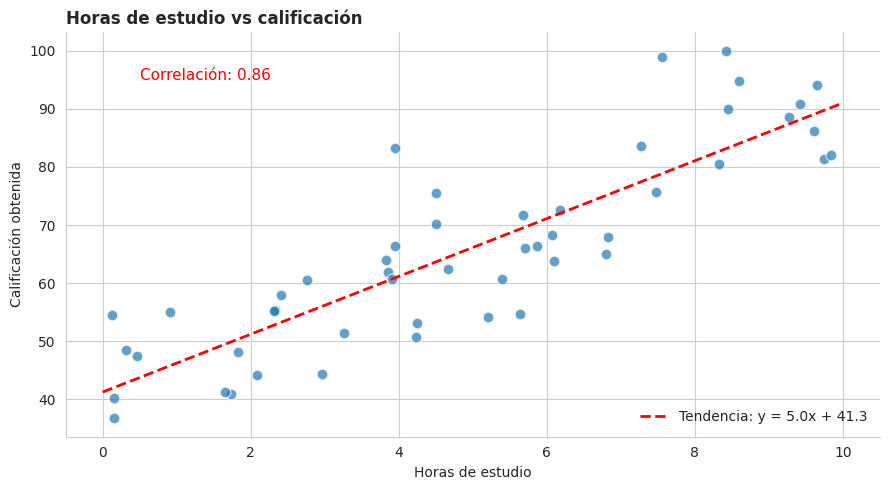

Coeficiente de correlación: 0.864


In [8]:
# Generar datos simulados con correlación positiva
horas_estudio = np.random.uniform(0, 10, 50)             # 50 estudiantes, 0-10 horas
ruido         = np.random.normal(0, 8, 50)               # Variabilidad realista
calificacion  = 40 + 5 * horas_estudio + ruido           # Relación lineal + ruido
calificacion  = np.clip(calificacion, 0, 100)            # Acotar entre 0 y 100

fig, ax = plt.subplots(figsize=(9, 5))

# Cada punto representa un estudiante
ax.scatter(horas_estudio, calificacion,
           color='#1f77b4', alpha=0.7, s=60, edgecolor='white')

# Línea de tendencia (regresión lineal simple) para visualizar la correlación
coef = np.polyfit(horas_estudio, calificacion, 1)        # ajuste de grado 1
x_linea = np.array([0, 10])
y_linea = coef[0] * x_linea + coef[1]
ax.plot(x_linea, y_linea, color='red', linestyle='--', linewidth=2,
        label=f'Tendencia: y = {coef[0]:.1f}x + {coef[1]:.1f}')

# Coeficiente de correlación de Pearson
correlacion = np.corrcoef(horas_estudio, calificacion)[0, 1]
ax.text(0.5, 95, f'Correlación: {correlacion:.2f}',
        fontsize=11, color='red')

ax.set_title('Horas de estudio vs calificación', loc='left')
ax.set_xlabel('Horas de estudio')
ax.set_ylabel('Calificación obtenida')
ax.legend(loc='lower right', frameon=False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

print(f'Coeficiente de correlación: {correlacion:.3f}')

**Interpretación:** Cada punto es un estudiante. La nube se inclina hacia arriba: **a más horas de estudio, mayor calificación**. La correlación cercana a 0,9 confirma una relación positiva fuerte.

**Lectura del coeficiente de correlación de Pearson:**

| Valor | Interpretación |
|---|---|
| Cerca de  +1 | Correlación positiva fuerte |
| Cerca de   0 | Sin correlación lineal |
| Cerca de  -1 | Correlación negativa fuerte |

**Importante:** correlación no implica causalidad. Que dos variables se muevan juntas no significa que una cause la otra.

### 3.7 Diagrama de caja (box plot)

**¿Qué es?** Muestra de un solo vistazo:
- La **mediana** (línea dentro de la caja).
- Los **cuartiles** Q1 y Q3 (bordes inferior y superior de la caja).
- El **rango** de los datos ("bigotes").
- Los **valores atípicos** (puntos fuera de los bigotes).

**¿Cuándo usarlo?** Para **resumir la dispersión** de un conjunto de datos numéricos y **comparar varios grupos** entre sí.

**Ejemplo:** comparar salarios entre departamentos.

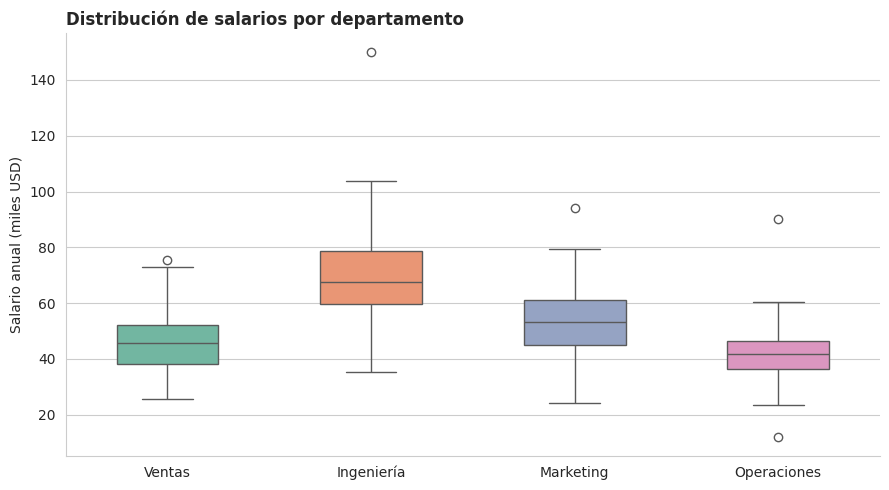

In [9]:
# Simular salarios para 4 departamentos (en miles de USD anuales)
salarios = pd.DataFrame({
    'Ventas':       np.random.normal(45, 10, 100),
    'Ingeniería':   np.random.normal(70, 15, 100),
    'Marketing':    np.random.normal(55, 12, 100),
    'Operaciones':  np.random.normal(40,  8, 100),
})

# Añadimos algunos valores atípicos artificiales para que el box plot los detecte
salarios.loc[0, 'Ingeniería']   = 150  # Un salario muy alto
salarios.loc[1, 'Operaciones']  = 90   # Otro outlier

fig, ax = plt.subplots(figsize=(9, 5))

sns.boxplot(data=salarios,
            palette='Set2',
            width=0.5,
            ax=ax)

ax.set_title('Distribución de salarios por departamento', loc='left')
ax.set_ylabel('Salario anual (miles USD)')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Cómo leer el box plot:**

```
         o   <- valores atípicos (outliers)
         |
       -----  <- bigote superior (máximo no atípico)
      |     |
      |-----|  <- Q3 (75% de los datos por debajo)
      |     |
      |-----|  <- mediana (50%)
      |     |
      |-----|  <- Q1 (25%)
      |     |
       -----  <- bigote inferior (mínimo no atípico)
         |
         o   <- valores atípicos
```

**Interpretación del ejemplo:** Ingeniería tiene los salarios más altos en mediana, pero también la mayor dispersión. Operaciones es el departamento con menor variabilidad. Los puntos sueltos por encima son **outliers**: salarios excepcionalmente altos respecto al resto.

### 3.8 Histograma

**¿Qué es?** Gráfico de barras que muestra la **distribución de frecuencias** de una variable numérica. El eje X se divide en intervalos ("bins") y la altura de cada barra cuenta cuántos valores caen en ese intervalo.

**¿Cuándo usarlo?** Para analizar **cómo se distribuyen** los valores de una sola variable: si están concentrados, dispersos, sesgados a un lado, etc.

**Ejemplo:** distribución de edades en un estudio de mercado.

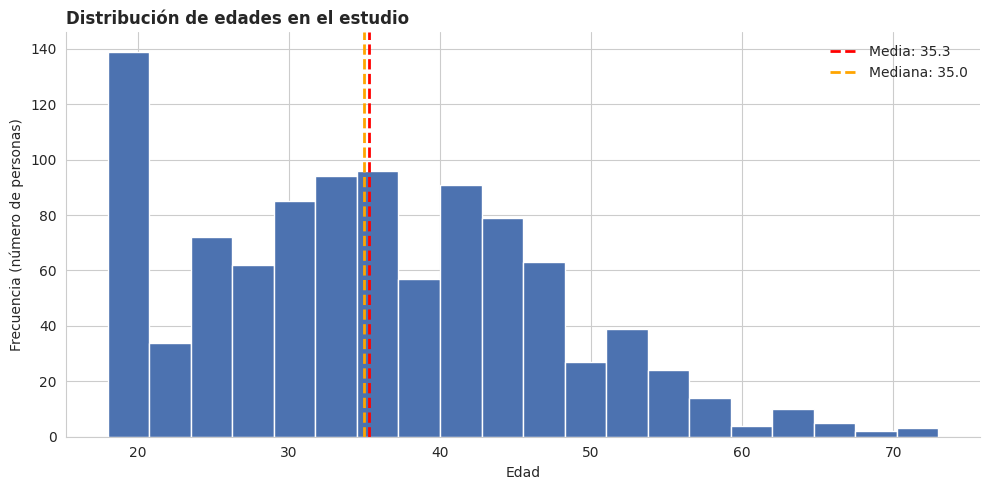

In [10]:
# Simulamos las edades de 1.000 personas con una distribución realista
edades = np.random.normal(loc=35, scale=12, size=1000)
edades = np.clip(edades, 18, 80).astype(int)   # acotar entre 18 y 80 años

fig, ax = plt.subplots(figsize=(10, 5))

# bins=20 divide el rango en 20 intervalos
ax.hist(edades, bins=20,
        color='#4c72b0', edgecolor='white')

# Líneas verticales para mostrar media y mediana
media   = np.mean(edades)
mediana = np.median(edades)

ax.axvline(media,   color='red',    linestyle='--', linewidth=2,
           label=f'Media: {media:.1f}')
ax.axvline(mediana, color='orange', linestyle='--', linewidth=2,
           label=f'Mediana: {mediana:.1f}')

ax.set_title('Distribución de edades en el estudio', loc='left')
ax.set_xlabel('Edad')
ax.set_ylabel('Frecuencia (número de personas)')
ax.legend(frameon=False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Interpretación:** La distribución se concentra alrededor de los 35 años, con forma aproximadamente simétrica ("campana"). Si la media y la mediana son muy parecidas, la distribución está balanceada; si difieren mucho, hay sesgo o valores extremos.

**Diferencia entre histograma y gráfico de barras:**

| Histograma | Gráfico de barras |
|---|---|
| Variable **numérica continua** | Variable **categórica** |
| Las barras están **pegadas** | Las barras están **separadas** |
| Eje X = intervalos numéricos | Eje X = categorías |

---
## 4. Análisis exploratorio: identificación de valores atípicos

Los **valores atípicos** (también llamados *outliers* o anomalías) son observaciones que se desvían significativamente del patrón general del conjunto de datos.

### ¿Por qué es importante identificarlos?

1. **Influencia en los resultados estadísticos:** un outlier puede mover bruscamente la media, la desviación estándar o las correlaciones.
2. **Sesgo en los modelos predictivos:** los algoritmos de Machine Learning pueden "distraerse" intentando predecir esos casos extremos.
3. **Impacto en el análisis de tendencias y patrones:** un outlier puede dar la impresión de un pico o caída que en realidad no es representativo.
4. **Indicadores de problemas o eventos especiales:** a veces los outliers no son errores, sino señales de algo importante (un fraude, un fallo en el sensor, una promoción exitosa).
5. **Interpretación correcta de los resultados:** entender por qué existen ayuda a contar la historia real detrás de los datos.

Veamos a continuación las **dos técnicas más usadas** para detectarlos.

### 4.1 Crear un dataset con valores atípicos

Para los ejemplos, simulamos las ventas diarias de una tienda durante 100 días, e introducimos algunos valores extremos a propósito.

In [11]:
# Datos normales: ventas diarias alrededor de 500 USD
ventas_normales = np.random.normal(loc=500, scale=50, size=100)

# Introducimos 5 valores atípicos (días con ventas anormalmente altas o bajas)
valores_atipicos = [1200, 1500, 50, 80, 1800]
ventas_completas = np.concatenate([ventas_normales, valores_atipicos])

# Convertimos a DataFrame
df = pd.DataFrame({'ventas_diarias': ventas_completas})

# Estadísticas descriptivas básicas
print('Resumen estadístico:')
print(df['ventas_diarias'].describe().round(2))

Resumen estadístico:
count     105.00
mean      525.74
std       189.67
min        50.00
25%       471.05
50%       505.00
75%       539.89
max      1800.00
Name: ventas_diarias, dtype: float64


### 4.2 Detectar outliers visualmente con un box plot

El box plot es la herramienta más rápida: cualquier punto que aparezca **fuera de los bigotes** es un outlier según el criterio del rango intercuartílico.

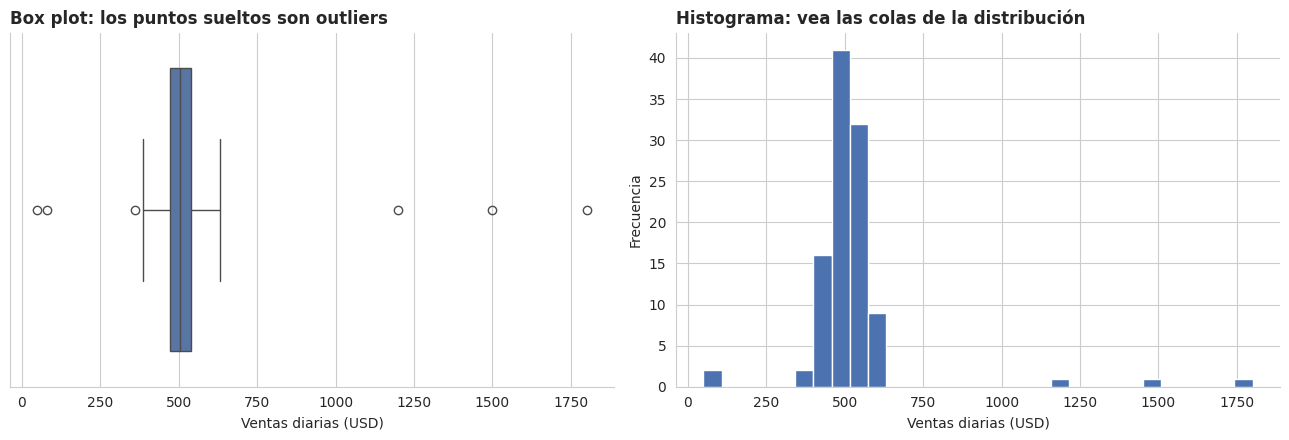

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Box plot: muestra los outliers como puntos individuales
sns.boxplot(x=df['ventas_diarias'], color='#4c72b0', ax=axes[0])
axes[0].set_title('Box plot: los puntos sueltos son outliers', loc='left')
axes[0].set_xlabel('Ventas diarias (USD)')

# Histograma: los outliers aparecen como barras aisladas en los extremos
axes[1].hist(df['ventas_diarias'], bins=30,
             color='#4c72b0', edgecolor='white')
axes[1].set_title('Histograma: vea las colas de la distribución', loc='left')
axes[1].set_xlabel('Ventas diarias (USD)')
axes[1].set_ylabel('Frecuencia')

for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### 4.3 Detectar outliers con el método del IQR (rango intercuartílico)

Es el método más usado y el que aplica el box plot por defecto. La idea:

1. Calcular Q1 (percentil 25) y Q3 (percentil 75).
2. Calcular IQR = Q3 - Q1.
3. Considerar outlier todo valor que esté:
   - Por debajo de **Q1 − 1,5 × IQR**
   - Por encima de **Q3 + 1,5 × IQR**

In [13]:
def detectar_outliers_iqr(serie):
    """
    Detecta valores atípicos usando el método del rango intercuartílico (IQR).

    Parámetros
    ----------
    serie : pd.Series
        Columna numérica de un DataFrame.

    Devuelve
    -------
    outliers : pd.Series
        Subconjunto de la serie con los valores considerados atípicos.
    limite_inferior, limite_superior : float
        Umbrales calculados.
    """
    Q1  = serie.quantile(0.25)
    Q3  = serie.quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    # Selecciona los valores fuera de los límites
    outliers = serie[(serie < limite_inferior) | (serie > limite_superior)]

    return outliers, limite_inferior, limite_superior


# Aplicar la función
outliers, lim_inf, lim_sup = detectar_outliers_iqr(df['ventas_diarias'])

print(f'Límite inferior: {lim_inf:.2f}')
print(f'Límite superior: {lim_sup:.2f}')
print(f'Número de outliers detectados: {len(outliers)}')
print('Valores atípicos:')
print(outliers.round(2).to_list())

Límite inferior: 367.78
Límite superior: 643.16
Número de outliers detectados: 6
Valores atípicos:
[359.69, 1200.0, 1500.0, 50.0, 80.0, 1800.0]


### 4.4 Detectar outliers con el método del Z-Score

Otra técnica común: convertir cada valor a su **distancia (en desviaciones estándar) respecto a la media**.

$$Z = \frac{x - \mu}{\sigma}$$

Un criterio típico es marcar como outlier cualquier observación con **|Z| > 3**, es decir, que esté a más de 3 desviaciones estándar de la media.

In [14]:
def detectar_outliers_zscore(serie, umbral=3):
    """
    Detecta outliers usando el Z-Score.
    Marca como atípico todo valor cuya distancia a la media,
    medida en desviaciones estándar, supere el umbral.
    """
    media = serie.mean()
    desv  = serie.std()

    z_scores = (serie - media) / desv
    outliers = serie[np.abs(z_scores) > umbral]

    return outliers, z_scores


outliers_z, z_scores = detectar_outliers_zscore(df['ventas_diarias'])

print(f'Outliers detectados con |Z| > 3: {len(outliers_z)}')
print('Valores y sus Z-scores:')
for valor, z in zip(outliers_z, z_scores[np.abs(z_scores) > 3]):
    print(f'  Valor: {valor:7.2f}  |  Z-score: {z:5.2f}')

Outliers detectados con |Z| > 3: 3
Valores y sus Z-scores:
  Valor: 1200.00  |  Z-score:  3.55
  Valor: 1500.00  |  Z-score:  5.14
  Valor: 1800.00  |  Z-score:  6.72


### 4.5 Visualizar los outliers detectados

Marcamos en rojo los valores atípicos sobre la serie original para verlos en contexto.

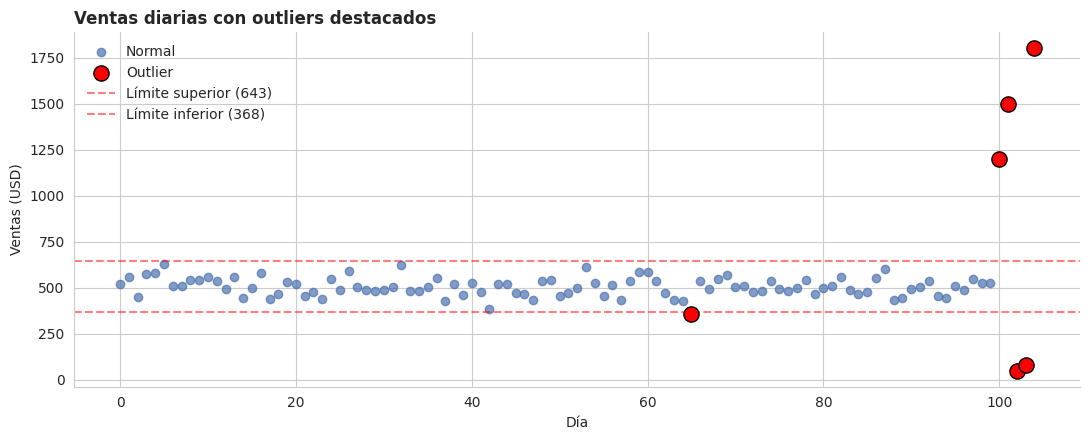

In [15]:
# Crear una marca booleana: True si el valor es atípico
df['es_outlier'] = (df['ventas_diarias'] < lim_inf) | (df['ventas_diarias'] > lim_sup)

fig, ax = plt.subplots(figsize=(11, 4.5))

# Puntos normales en azul
normales = df[~df['es_outlier']]
ax.scatter(normales.index, normales['ventas_diarias'],
           color='#4c72b0', alpha=0.7, label='Normal')

# Outliers en rojo y más grandes para destacarlos
atipicos = df[df['es_outlier']]
ax.scatter(atipicos.index, atipicos['ventas_diarias'],
           color='red', s=120, edgecolor='black', label='Outlier', zorder=5)

# Líneas de los límites IQR como referencia
ax.axhline(lim_sup, color='red', linestyle='--', alpha=0.5,
           label=f'Límite superior ({lim_sup:.0f})')
ax.axhline(lim_inf, color='red', linestyle='--', alpha=0.5,
           label=f'Límite inferior ({lim_inf:.0f})')

ax.set_title('Ventas diarias con outliers destacados', loc='left')
ax.set_xlabel('Día')
ax.set_ylabel('Ventas (USD)')
ax.legend(loc='upper left', frameon=False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

### 4.6 ¿Qué hacer con los outliers?

**No siempre se eliminan.** La decisión depende del contexto:

| Situación | Acción recomendada |
|---|---|
| Error de captura (tipo digitar 5000 en vez de 500) | Corregir o eliminar |
| Lectura defectuosa de un sensor | Eliminar o imputar |
| Evento real (Black Friday, fraude detectado, promoción) | **Conservar** y analizar aparte |
| No se sabe el origen | Analizar con y sin él, y comparar conclusiones |

**Comparemos cómo cambia la media** al eliminar los outliers:

In [16]:
# Crear una versión "limpia" del dataset (sin outliers)
df_limpio = df[~df['es_outlier']].copy()

# Comparar estadísticas antes y después
comparacion = pd.DataFrame({
    'Con outliers':   [df['ventas_diarias'].mean(),
                       df['ventas_diarias'].median(),
                       df['ventas_diarias'].std()],
    'Sin outliers':   [df_limpio['ventas_diarias'].mean(),
                       df_limpio['ventas_diarias'].median(),
                       df_limpio['ventas_diarias'].std()],
}, index=['Media', 'Mediana', 'Desv. estándar']).round(2)

print('Comparación de estadísticas:')
print(comparacion)

# Diferencia porcentual en la media
dif_pct = (comparacion.loc['Media', 'Con outliers']
           - comparacion.loc['Media', 'Sin outliers']) / comparacion.loc['Media', 'Sin outliers'] * 100
print(f'\nLos outliers inflaron la media un {dif_pct:.1f}% respecto al valor real.')

Comparación de estadísticas:
                Con outliers  Sin outliers
Media                 525.74        507.20
Mediana               505.00        505.00
Desv. estándar        189.67         48.16

Los outliers inflaron la media un 3.7% respecto al valor real.


**Observación clave:** la **mediana** apenas cambia, pero la **media** sí. Por eso, cuando hay outliers conviene reportar la mediana, que es más robusta.

---

## 5. Resumen final: ¿qué gráfico elijo?

Una guía rápida para decidir:

| Pregunta de negocio | Gráfico recomendado |
|---|---|
| ¿Cuánto vende cada producto? | Barras / Columnas |
| ¿Cómo evolucionan las ventas en el tiempo? | Líneas |
| ¿Qué porcentaje del total representa cada categoría? | Circular (con pocas categorías) |
| ¿Cómo se distribuyen las edades de mis clientes? | Histograma |
| ¿Hay relación entre dos variables numéricas? | Dispersión |
| ¿Cómo varían los salarios entre departamentos? | Box plot |
| ¿Hay zonas calientes en mi matriz de datos? | Heatmap |

Y antes de visualizar, **siempre** explora los datos:

1. Revisa el resumen estadístico (`df.describe()`).
2. Busca valores faltantes (`df.isna().sum()`).
3. Detecta outliers con IQR o Z-score.
4. Decide qué hacer con cada anomalía según su origen.

---

**Universidad Autónoma de Manizales — Educación Continuada**

*Sergio Alejandro Holguín García*